# PHASE 2: Data Cleaning & EDA
**Traceability**
- Issue ID: #2 Data Cleaning & EDA

**External References**:
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (Constant Sensor Removal)
- [Carl Kirstein - Predictive Maintenance](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) (Outlier Handling)
- [Carl Kirstein - Predictive Maintenance](https://www.kaggle.com/code/carlkirstein/predictive-maintenance-nasa-turbofan-regression) (Correlation Analysis)
- [Wassim Derbel - NASA Predictive Maintenance](https://www.kaggle.com/code/wassimderbel/nasa-predictive-maintenance-rul) (Trend Visualization)

## 1. Objectives
focus more on sensor columns

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# ── Plotting Config ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})
COLORS = ['#1F4E79', '#2E75B6', '#70AD47', '#FF7043', '#AB47BC']
COLORSplt = ['#313695', '#4575B4', '#FFFFFF', '#FEE090', '#D73027']

# ── Reproducibility Config ──────────────────────────────────────────────
np.random.seed(42)

# ── Global Config ────────────────────────────────────────────────────────
DATA_DIR = Path('../data')
PROCESSED_DIR = Path('../data/processed')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

COL_NAMES = (
    ['unit_number', 'time_cycles'] +
    ['setting_1', 'setting_2', 'setting_3'] +
    [f's_{i}' for i in range(1, 22)]   # s_1 ... s_21
)

### 2.1 Load Raw Data
Load the raw training and test data.

In [2]:
df_train = pd.read_csv(DATA_DIR / 'train_FD001.txt', sep=r'\s+', header=None, index_col=False, names=COL_NAMES)
df_valid = pd.read_csv(DATA_DIR / 'test_FD001.txt', sep=r'\s+', header=None, index_col=False, names=COL_NAMES)
print(f"✅ Data loaded: Train {df_train.shape}, Valid {df_valid.shape}")


✅ Data loaded: Train (20631, 26), Valid (13096, 26)


In [3]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
s_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
s_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [4]:
df_valid.describe().T


,count,mean,std,min,25%,50%,75%,max
unit_number,13096.0,51.543907,2.828942e+01,1.0000,28.0000,52.0000,76.0000,100.0000
time_cycles,13096.0,76.836515,5.305775e+01,1.0000,33.0000,69.0000,113.0000,303.0000
setting_1,13096.0,-0.000011,2.202685e-03,-0.0082,-0.0015,-0.0000,0.0015,0.0078
setting_2,13096.0,0.000004,2.940306e-04,-0.0006,-0.0002,-0.0000,0.0003,0.0007
setting_3,13096.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
s_1,13096.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
s_2,13096.0,642.475088,4.008993e-01,641.1300,642.1975,642.4600,642.7400,644.3000
s_3,13096.0,1588.099204,5.003274e+00,1569.0400,1584.6000,1587.9900,1591.3625,1607.5500
s_4,13096.0,1404.735362,6.688309e+00,1384.3900,1399.9500,1404.4400,1409.0500,1433.3600
s_5,13096.0,14.620000,1.776425e-15,14.6200,14.6200,14.6200,14.6200,14.6200


Train and Valid Data Descriptive Statistics are similar meaning we can just do data analysis on train data first to clean data.

### 2.2 Diagnostic: Sensor Variance Analysis
We visualize the standard deviation of each sensor to identify those that do not change over time (constant sensors). These provide no predictive value.

s_1: 0.0000
s_10: 0.0000
s_19: 0.0000
s_18: 0.0000
s_16: 0.0000
s_5: 0.0000
s_6: 0.0014
s_15: 0.0375
s_8: 0.0710
s_13: 0.0719
s_21: 0.1083
s_20: 0.1807
s_11: 0.2671
s_2: 0.5001
s_12: 0.7376
s_7: 0.8851
s_17: 1.5488
s_3: 6.1311
s_4: 9.0006
s_14: 19.0762
s_9: 22.0829


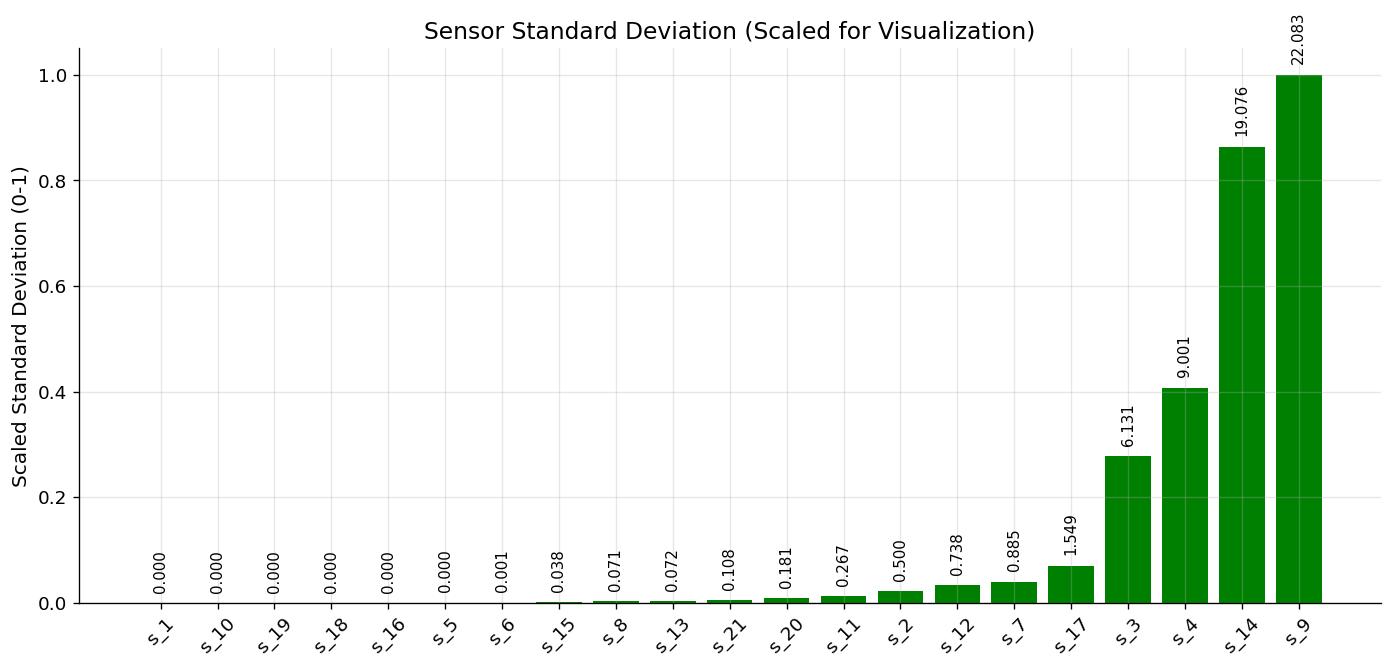

In [5]:
def visualize_sensor_variance_scaled(df, threshold=0.01):
    sensor_cols = [f's_{i}' for i in range(1, 22)]
    sensor_std = df[sensor_cols].std().sort_values()
    
    # Min-Max scaling to 0-1 range
    scaler = MinMaxScaler()
    sensor_std_scaled = scaler.fit_transform(sensor_std.values.reshape(-1, 1)).flatten()
    
    plt.figure(figsize=(14,6))
    colors = ['red' if std < threshold else 'green' for std in sensor_std]  # threshold still in original scale
    
    bars = plt.bar(sensor_std.index, sensor_std_scaled, color=colors)
    
    # Annotate with original std values
    for bar, orig_std in zip(bars, sensor_std.values):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{orig_std:.3f}',
                 ha='center', va='bottom', fontsize=9, rotation=90)
    
    plt.title('Sensor Standard Deviation (Scaled for Visualization)', fontsize=14)
    plt.ylabel('Scaled Standard Deviation (0-1)', fontsize=12)
    plt.xticks(rotation=45)
    plt.show()
    
    return sensor_std[sensor_std < threshold].index.tolist()

# Compute std for each sensor
sensor_std = df_train[[f's_{i}' for i in range(1, 22)]].std()
# Sort by std
sensor_std_sorted = sensor_std.sort_values()
# Print each sensor with its std
for sensor_name, std_val in sensor_std_sorted.items():
    print(f"{sensor_name}: {std_val:.4f}")

constant_sensors = visualize_sensor_variance_scaled(df_train)

Anything with std ≈ 0 can be safely dropped: s_1, s_5, s_10, s_16, s_18, s_19

Lets say threshold = 0.01

Low but not zero (s_6, s_8, s_15) — might be near-constant. 
Can consider dropping later if they don’t correlate with RUL.

In [6]:
def add_RUL_column(df):
    train_grouped_by_unit = df.groupby(by='unit_number') 
    max_time_cycles = train_grouped_by_unit['time_cycles'].max() 
    merged = df.merge(max_time_cycles.to_frame(name='max_time_cycle'), left_on='unit_number',right_index=True)
    merged["RUL"] = merged["max_time_cycle"] - merged['time_cycles']
    merged = merged.drop("max_time_cycle", axis=1) 
    return merged

def add_RUL_column_test(df_test, rul_file):
    """Add correct RUL to test data using ground truth from RUL_FDxxx.txt.
    
    Test trajectories are truncated before failure, so RUL cannot be computed
    from max_time_cycle. Instead, the RUL file provides the true RUL at the
    last recorded cycle of each engine. For earlier cycles:
        RUL = ground_truth_rul + (last_cycle_in_test - current_cycle)
    """
    rul_gt = pd.read_csv(rul_file, sep=r'\s+', header=None, names=['RUL_last'])
    rul_gt['unit_number'] = range(1, len(rul_gt) + 1)
    
    max_cycles = df_test.groupby('unit_number')['time_cycles'].max().reset_index()
    max_cycles.columns = ['unit_number', 'max_time_cycle']
    
    merged = df_test.merge(max_cycles, on='unit_number')
    merged = merged.merge(rul_gt, on='unit_number')
    merged['RUL'] = merged['RUL_last'] + (merged['max_time_cycle'] - merged['time_cycles'])
    merged = merged.drop(columns=['max_time_cycle', 'RUL_last'])
    return merged

train = add_RUL_column(df_train)
valid = add_RUL_column_test(df_valid, DATA_DIR / 'RUL_FD001.txt')
print(f"✅ RUL added: train (max_cycle method), valid (ground truth from RUL_FD001.txt)")
print(f"   Valid last-cycle RUL sample: {valid.groupby('unit_number')['RUL'].last().head().tolist()}")

✅ RUL added: train (max_cycle method), valid (ground truth from RUL_FD001.txt)
   Valid last-cycle RUL sample: [112, 98, 69, 82, 91]


In [7]:
#Rul analysis
maxrul_u = train.groupby('unit_number').max().reset_index()
maxrul_u.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,192,0.0047,0.0005,100.0,518.67,644.21,1605.44,1432.52,14.62,...,2388.35,8140.58,8.5227,0.03,398,2388,100.0,39.18,23.4999,191
1,2,287,0.0076,0.0006,100.0,518.67,643.94,1610.10,1431.17,14.62,...,2388.26,8175.57,8.5377,0.03,398,2388,100.0,39.24,23.6005,286
2,3,179,0.0058,0.0005,100.0,518.67,643.93,1606.50,1438.51,14.62,...,2388.20,8255.34,8.5363,0.03,399,2388,100.0,39.23,23.5181,178
3,4,189,0.0059,0.0006,100.0,518.67,644.53,1612.11,1434.12,14.62,...,2388.17,8259.42,8.5462,0.03,399,2388,100.0,39.21,23.5074,188
4,5,269,0.0055,0.0005,100.0,518.67,644.02,1609.41,1434.59,14.62,...,2388.23,8215.19,8.5410,0.03,398,2388,100.0,39.29,23.5503,268


Visualize on RUL column correlation with sensor columns

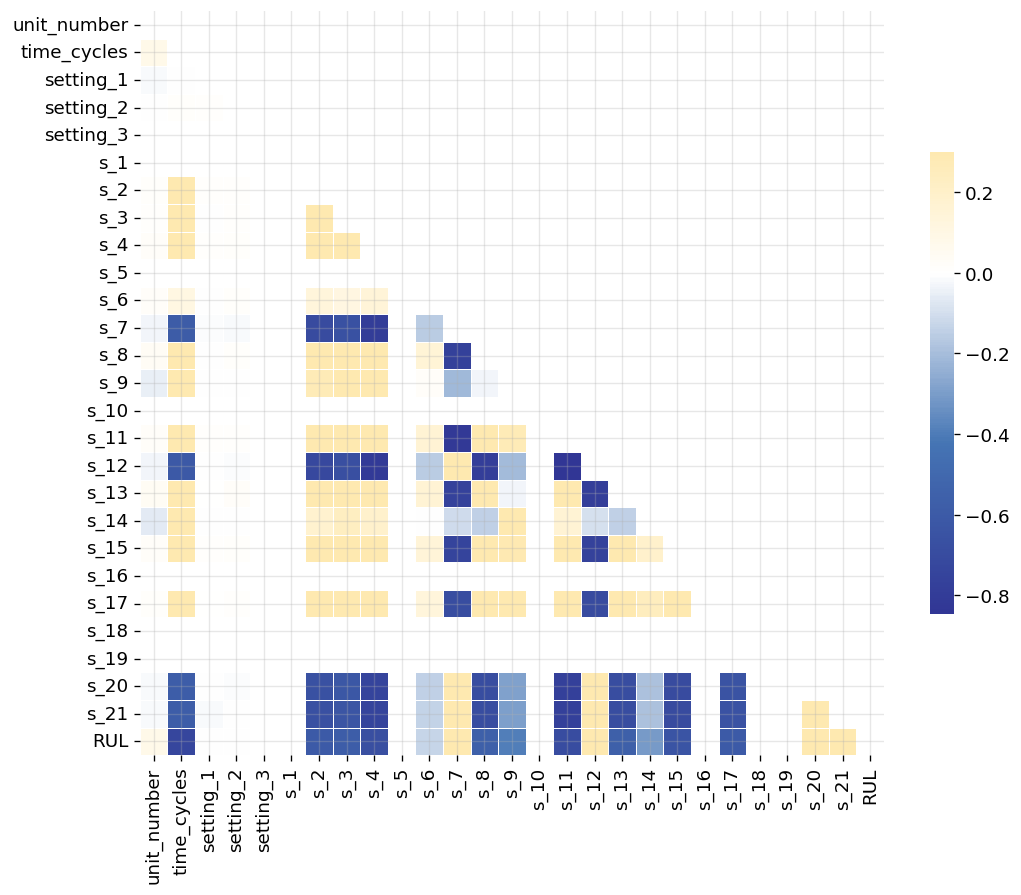

In [8]:
# Create a colormap from your colors
cmap = LinearSegmentedColormap.from_list("custom_cmap", COLORSplt)

# Compute the correlation matrix
corr = train.corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(10, 10))

# Draw the heatmap
sns.heatmap(
    corr, 
    mask=mask, 
    cmap=cmap,        # use your custom colormap
    vmax=.3, 
    center=0, 
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .5}
)

plt.show()


Can be safely dropped: s_1, s_5, s_10, s_16, s_18, s_19 ,as they are all having std no correlation to RUL

Not sure: (s_6, s_8, s_15) — might be near-constant. 

Need further analysis to confirm if these sensors are indeed constant or just near-constant.

We notice that some features of our data-set are highly correlated with the target value RUL, other features present a low correlation which will be dropped later.


In [9]:
# List of sensors to drop
sensors_to_drop = ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19']

# Drop from train and test safely
df_train = df_train.drop(columns=sensors_to_drop, errors='ignore')
df_valid = df_valid.drop(columns=sensors_to_drop, errors='ignore')

# Remaining sensors
remaining_sensors = [c for c in df_train.columns if c.startswith('s_')]

print(f"✅ Dropped sensors_to_drop: {sensors_to_drop} . Remaining: {len(remaining_sensors)}")


✅ Dropped sensors_to_drop: ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19'] . Remaining: 15


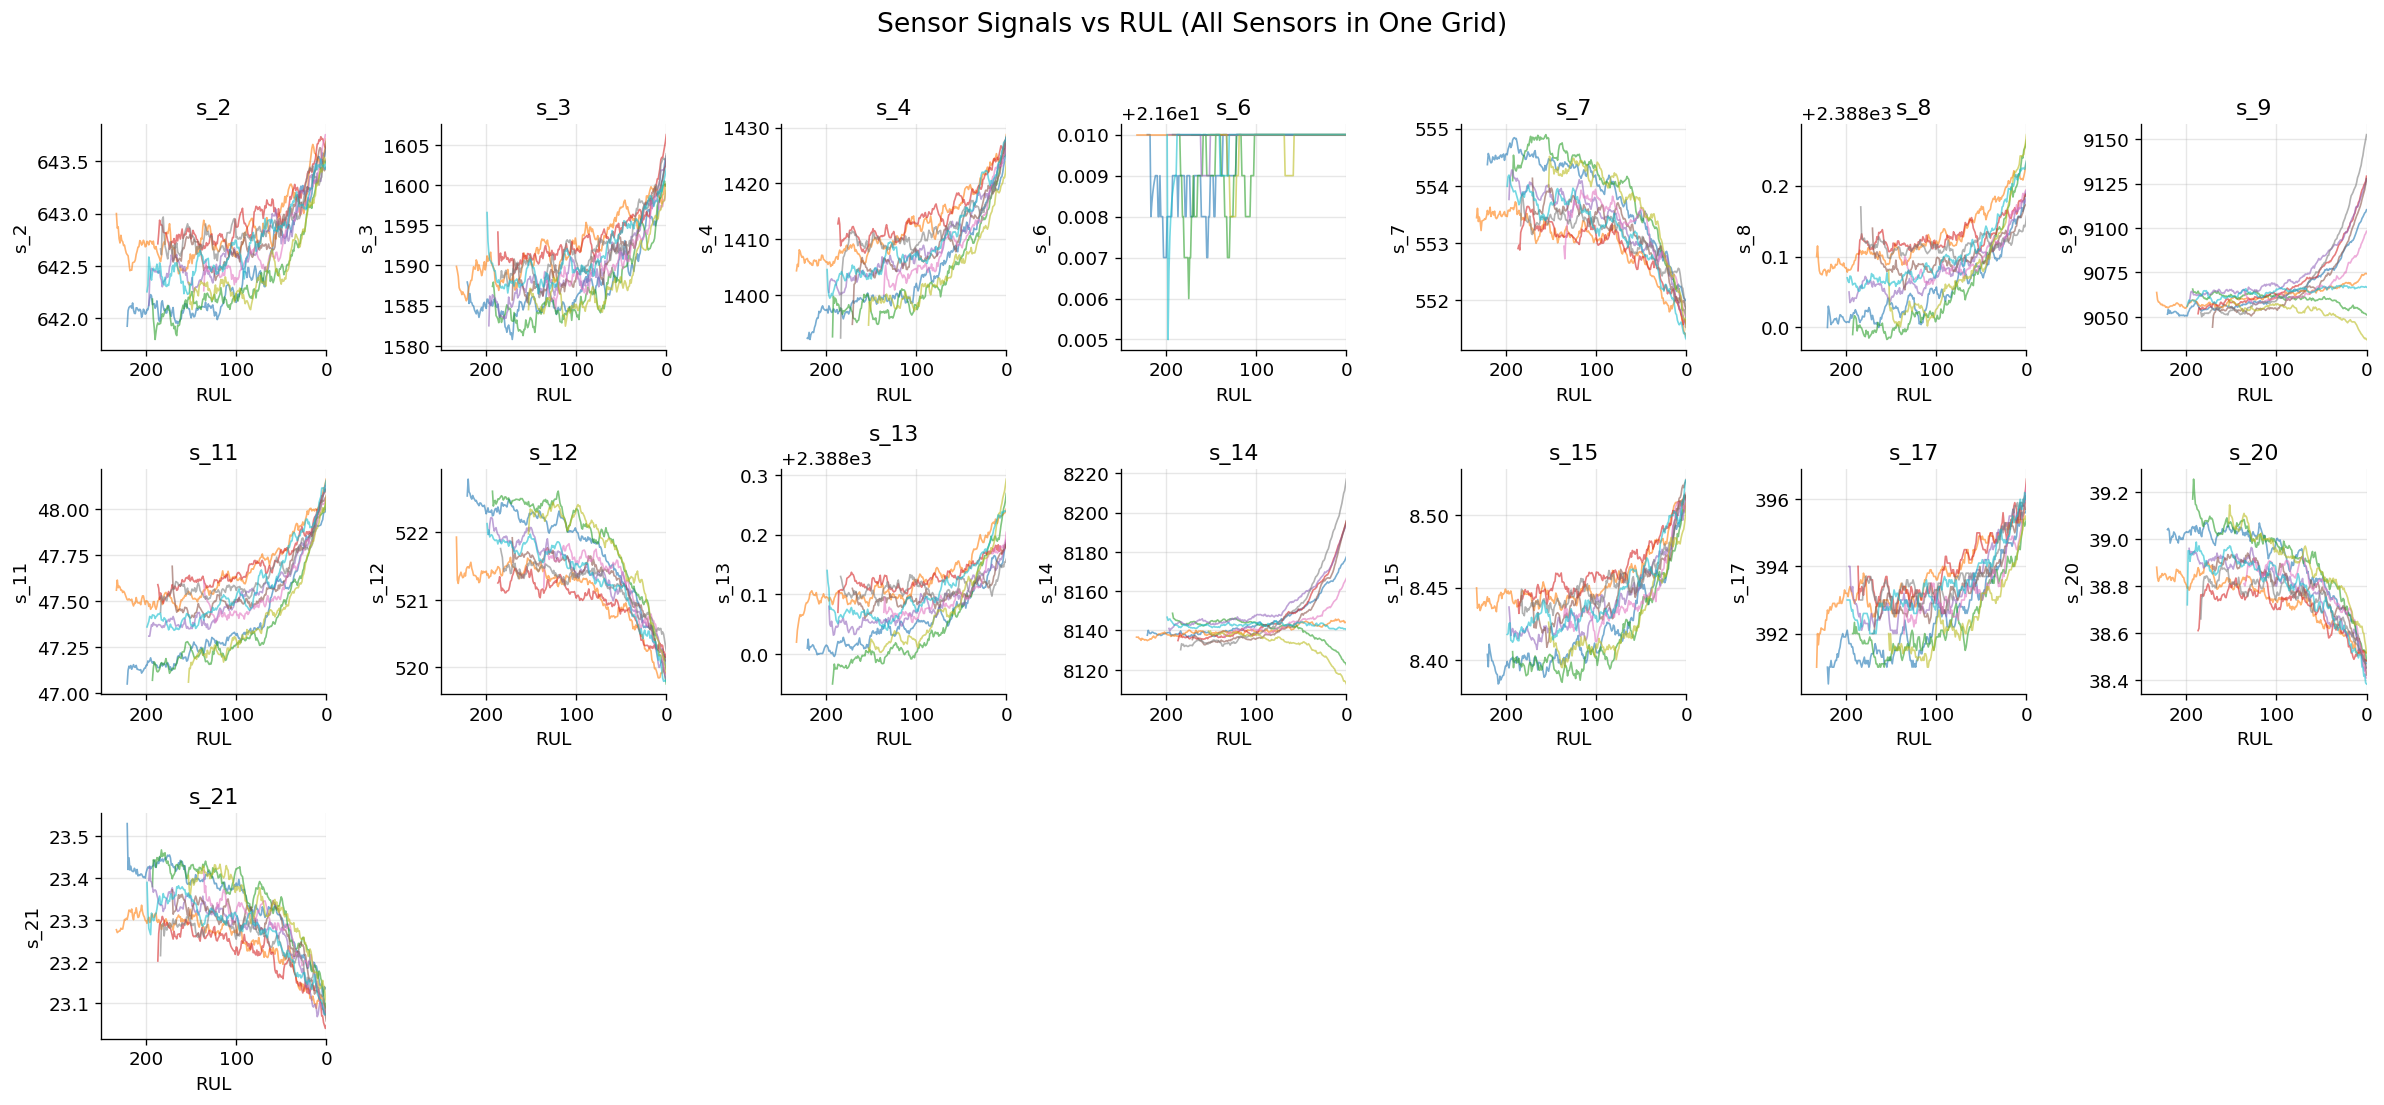

In [10]:
def plot_signal_grid(df):
    """Plot all remaining sensor signals vs RUL in a single grid for better visualization."""
    
    # Use only sensors that still exist in the DataFrame
    sensor_cols = [c for c in df.columns if c.startswith('s_')]
    n_sensors = len(sensor_cols)
    
    n_cols = 7
    n_rows = int(np.ceil(n_sensors / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 3 * n_rows))
    axes = axes.flatten()  # Flatten in case of multiple rows
    
    for i, sensor in enumerate(sensor_cols):
        ax = axes[i]
        for unit in df['unit_number'].unique():
            if unit % 10 == 0:  # Plot only some units for clarity
                subset = df[df['unit_number'] == unit].sort_values('time_cycles')
                smoothed = subset[sensor].rolling(10, min_periods=1).mean()
                ax.plot(subset['RUL'], smoothed, alpha=0.6, linewidth=1)
        ax.set_xlim(250, 0)
        ax.set_ylabel(sensor)  # Just use sensor column name
        ax.set_xlabel('RUL')
        ax.set_title(sensor)
    
    # Remove any unused axes
    for j in range(n_sensors, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle('Sensor Signals vs RUL (All Sensors in One Grid)', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


# Usage: RUL already added earlier (train via max_cycle, valid via RUL_FD001.txt ground truth)
# Re-add RUL to df_train/df_valid after sensor columns were dropped
df_train = add_RUL_column(df_train)
df_valid = add_RUL_column_test(df_valid, DATA_DIR / 'RUL_FD001.txt')
plot_signal_grid(df_train)

Here we can saw again that our choice in dropping ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19'] is justified by the sensor signal distribution as there are constant shown in each of the sensor signal.

📊 Sensor Outlier Summary:
s_2: 128 outliers (0.62%) → Low outlier presence
s_3: 165 outliers (0.80%) → Low outlier presence
s_4: 120 outliers (0.58%) → Low outlier presence
s_6: 406 outliers (1.97%) → Moderate outlier presence
s_7: 110 outliers (0.53%) → Low outlier presence
s_8: 320 outliers (1.55%) → Moderate outlier presence
s_9: 1686 outliers (8.17%) → High outlier presence
s_11: 167 outliers (0.81%) → Low outlier presence
s_12: 146 outliers (0.71%) → Low outlier presence
s_13: 161 outliers (0.78%) → Low outlier presence
s_14: 1543 outliers (7.48%) → High outlier presence
s_15: 120 outliers (0.58%) → Low outlier presence
s_17: 81 outliers (0.39%) → Low outlier presence
s_20: 117 outliers (0.57%) → Low outlier presence
s_21: 136 outliers (0.66%) → Low outlier presence


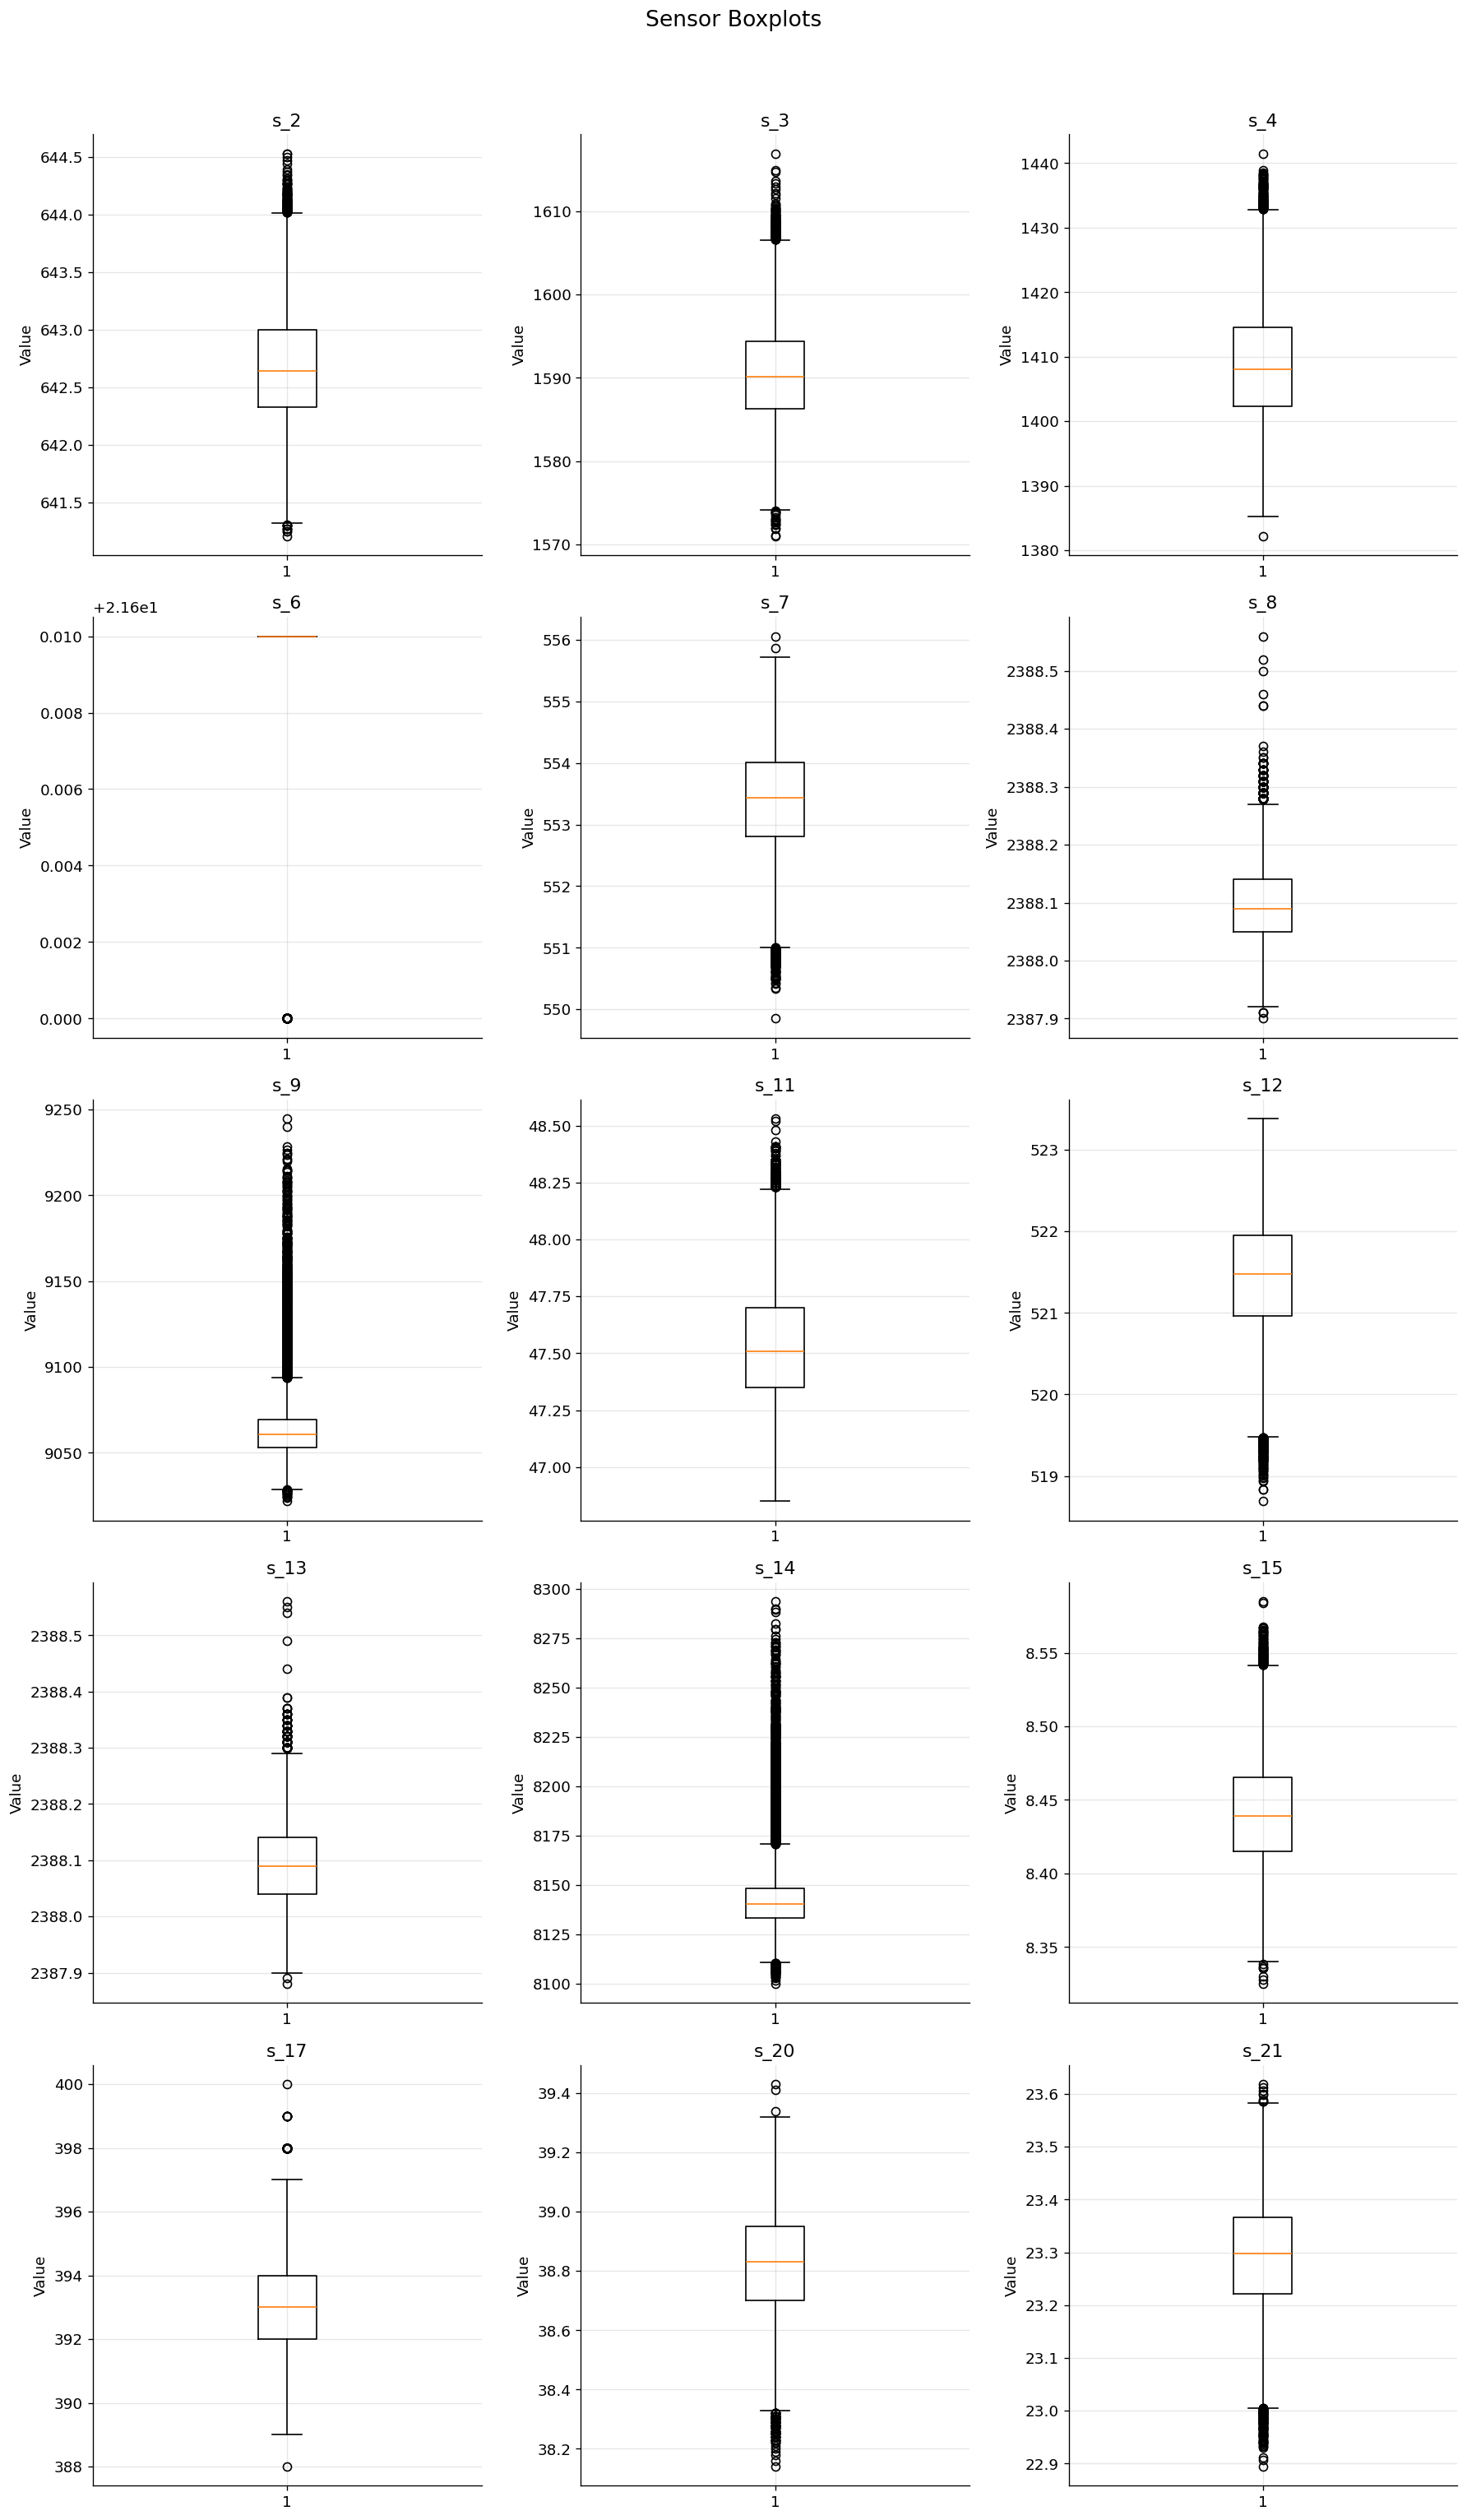

In [11]:
def boxplot_sensors_grid(df, sensor_names, n_cols=3):
    """
    Plot boxplots for multiple sensors in a grid and give textual outlier summary.
    
    Args:
        df: DataFrame containing the sensor columns.
        sensor_names: List of sensor column names (e.g., ['s_1', 's_2', ...]).
        n_cols: Number of columns in the grid.
    """
    # Keep only sensors that exist in df
    sensor_names = [s for s in sensor_names if s in df.columns]

    n_sensors = len(sensor_names)
    n_rows = (n_sensors + n_cols - 1) // n_cols  # ceil division for rows

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))
    axes = axes.flatten()  # flatten for easy iteration

    print("📊 Sensor Outlier Summary:")
    for i, sensor in enumerate(sensor_names):
        # Boxplot
        axes[i].boxplot(df[sensor])
        axes[i].set_title(sensor)
        axes[i].set_ylabel('Value')

        # Outlier detection using IQR
        Q1 = df[sensor].quantile(0.25)
        Q3 = df[sensor].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[sensor] < Q1 - 1.5*IQR) | (df[sensor] > Q3 + 1.5*IQR)][sensor]
        n_outliers = len(outliers)
        perc_outliers = n_outliers / len(df) * 100

        # Decide seriousness
        if perc_outliers < 1:
            severity = "Low"
        elif perc_outliers < 5:
            severity = "Moderate"
        else:
            severity = "High"

        print(f"{sensor}: {n_outliers} outliers ({perc_outliers:.2f}%) → {severity} outlier presence")

    # Remove any extra subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.suptitle('Sensor Boxplots', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


# Generate sensor_names from remaining columns
sensor_names = [c for c in train.columns if c.startswith('s_')]

# Call the function
boxplot_sensors_grid(df_train, sensor_names)


In [12]:
df_train['s_6'].describe()

count    20631.000000
mean        21.609803
std          0.001389
min         21.600000
25%         21.610000
50%         21.610000
75%         21.610000
max         21.610000
Name: s_6, dtype: float64

In [13]:
# Ensure column names have no extra spaces
df_train.columns = df_train.columns.str.strip()

# Select the sensor
sensor = "s_6"

# Compute Q1, Q3 and IQR
Q1 = df_train[sensor].quantile(0.25)
Q3 = df_train[sensor].quantile(0.75)
IQR = Q3 - Q1

# Compute lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# List outliers only
outliers_s6 = df_train[(df_train[sensor] < lower_bound) | (df_train[sensor] > upper_bound)]

# Display the rows with outlier values in s_6
print(outliers_s6[["unit_number", "time_cycles", "s_6"]])

       unit_number  time_cycles   s_6
192              2            1  21.6
194              2            3  21.6
196              2            5  21.6
200              2            9  21.6
201              2           10  21.6
...            ...          ...   ...
20165           98           76  21.6
20252           99            7  21.6
20286           99           41  21.6
20432          100            2  21.6
20490          100           60  21.6

[406 rows x 3 columns]


406 rows of 21.6 / 20225 rows of 21.61 

We can confirm that s_6 sensor 6 has very close to constant values.
Hence we can safely drop s_6.

In [14]:
# Drop from train and test safely
df_train = df_train.drop(columns=['s_6'], errors='ignore')
df_valid = df_valid.drop(columns=['s_6'], errors='ignore')

# Remaining sensors
remaining_sensors = [c for c in df_train.columns if c.startswith('s_')]

print(f"✅ Dropped s_6 . Remaining: {len(remaining_sensors)}")


✅ Dropped s_6 . Remaining: 14


In [15]:
df_train['unit_number'] = df_train['unit_number'].astype('float64')
df_train['time_cycles'] = df_train['time_cycles'].astype('float64')
df_valid['unit_number'] = df_valid['unit_number'].astype('float64')
df_valid['time_cycles'] = df_valid['time_cycles'].astype('float64')

df_train['s_17'] = df_train['s_17'].astype('float64')
df_valid['s_17'] = df_valid['s_17'].astype('float64')

df_train['RUL'] = df_train['RUL'].astype('float64')
df_valid['RUL'] = df_valid['RUL'].astype('float64')


In [16]:

df_train.dtypes

unit_number    float64
time_cycles    float64
setting_1      float64
setting_2      float64
setting_3      float64
s_2            float64
s_3            float64
s_4            float64
s_7            float64
s_8            float64
s_9            float64
s_11           float64
s_12           float64
s_13           float64
s_14           float64
s_15           float64
s_17           float64
s_20           float64
s_21           float64
RUL            float64
dtype: object

In [17]:
df_valid.dtypes

unit_number    float64
time_cycles    float64
setting_1      float64
setting_2      float64
setting_3      float64
s_2            float64
s_3            float64
s_4            float64
s_7            float64
s_8            float64
s_9            float64
s_11           float64
s_12           float64
s_13           float64
s_14           float64
s_15           float64
s_17           float64
s_20           float64
s_21           float64
RUL            float64
dtype: object

convert all columns of data to float64 

In [18]:
# Save
df_train.to_csv(PROCESSED_DIR / 'train_cleaned.csv', index=False)
df_valid.to_csv(PROCESSED_DIR / 'valid_cleaned.csv', index=False)
print(f"\n✅ Cleaned & engineered data saved to {PROCESSED_DIR}")



✅ Cleaned & engineered data saved to ..\data\processed
